# PG&E Hosting Capacity Calculations

**Inputs:**

- `zillow`, full zillow data with imputed units

- `pge`, Pacific Gas & Electric Circuit Segments with ICA Capacities

- `pge_cust`, Pacific Gas & Electric customer data

- `pge_territory`, Pacific Gas & Electric Service Territory

**Outputs:**

- `pge_census_map`, each California census tract has its corresponding average hosting capacity per household

In [29]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

# set option to see all data frame columns
pd.set_option('display.max_columns', None)

In [ ]:
# Load data
# zillow = gpd.read_parquet('~/../../capstone/electrigrid/data/zillow_complete_units.parquet').to_crs(epsg=3310)
zillow = gpd.read_parquet("~/../../capstone/electrigrid/data/final_building.parquet").to_crs(epsg=3310)
pge = gpd.read_parquet("~/../../capstone/electrigrid/data/utilities/pge_updated/pge.parquet").to_crs(epsg=3310)
pge_cust = pd.read_csv("~/../../capstone/electrigrid/data/utilities/pge_updated/pge_cust.csv")
utility_ter = gpd.read_file("~/../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson").to_crs(epsg=3310)
census = gpd.read_file("~/../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs(3310)

## Clean data

In [31]:
# clean column names 
pge.columns = pge.columns.str.strip().str.lower().str.replace(r'[^\w]', '_', regex=True)
pge_cust.columns = pge_cust.columns.str.strip().str.lower().str.replace(r'[^\w]', '_', regex=True)

In [32]:
# convert capacity columns to MW
cols = pge.columns[pge.columns.str.contains('_kw')]

for col in cols:
    pge[col] = pge[col] / 1000

# change column names to indicate megawatts
pge.columns = pge.columns.str.replace('kw', 'mw')

In [33]:
# convert feederid column to str in pge_cust
pge_cust['feederid'] = pge_cust['feederid'].astype(str)

In [34]:
pge_territory = utility_ter[utility_ter['Acronym'] == 'PG&E']

In [35]:
pge = pge.dropna(subset=['genericpvcapacity_mw', 'loadcapacity_mw'])

### Calculate customer usage percentages

In [36]:
# Calculate total customers per feeder
cols = pge_cust.columns[pge_cust.columns.str.contains('customer')]
pge_cust['total_customers'] = pge_cust[cols].sum(axis=1)

# Percentage of each customer type
pge_cust['res_pct'] = pge_cust['residential_customer_count'] / pge_cust['total_customers'] * 100

In [37]:
# pge = pge[['FeederId', 'CSV_LineSection','LoadCapacity_kW', 'GenCapacity_kW', 'GenericPVCapacity_kW', 'GenCapacity_no_OpFlex_kW', 'GenericCapacity_no_OpFlex_kW', 'geometry']]
# pge.head(2)

In [38]:
pge = pge.merge(pge_cust[['feederid', 'res_pct', 'existing_distributed_generation__kw_']], how='left', on='feederid')

# Calculating Hosting Capacity for a Feederline with Values!

## Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 

In order to match the workflow below, I will rename some variables first.

#### Change column names to match other utilites

In [39]:
# circuits = circuits.rename(columns = {'FeederId':'circuit_id',
#                                         'CSV_LineSection':'segment_id',
#                                         'LoadCapacity_kW':'load_cap',
#                                         'GenCapacity_no_OpFlex_kW':'gencap',
#                                         'GenCapacity_kW':'gencap_opflex',
#                                         'GenericCapacity_no_OpFlex_kW':'gencap_pv',
#                                         'GenericPVCapacity_kW':'gencap_pv_opflex'})

### Step 1a: Multiply generations by residential customer percentage

In [40]:
# for col in ['gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'load_cap']:
#     circuits[col] = circuits[col] * (circuits['perc_res'] / 100)

### Step 1b: Crop zillow buildings to only with PG&E territory

In [41]:
# crop zillow to only within sce territory
zillow_pge = gpd.sjoin(zillow, pge_territory[['geometry']], how='inner', predicate='within')[zillow.columns]

### Step 1b: Join buildings to nearest segment

In [42]:
linked = gpd.sjoin_nearest(zillow_pge, pge, how='left', distance_col='dist_to_line_m')

### Step 1c: Filter for homes that are less than 1000m away from the nearest feederline
If they are more than 1 km away, we assume they get their power from a different source.

In [43]:
# buildings_linked = buildings_linked[buildings_linked['dist_to_line_m'] < 1000]

## Step 2: Get housing aggregations

In [44]:
# sum housing units per section_id 
units_per_seg = linked.groupby('csv_linesection')['unit'].sum().rename('tothh_seg')
linked = linked.merge(units_per_seg, on='csv_linesection')
# drop observations with no housing units, will avoid divide-by-zero error in per-household capacity calculation
linked = linked[linked['tothh_seg'] > 0]

# sum housing units across all segments in each circuit (tothh_ctot in Brockway Eq. 8)
units_per_circuit = linked.groupby('feederid')['unit'].sum().rename('tothh_circuit')
linked = linked.merge(units_per_circuit, on='feederid')

### Calculate *DER_remain* function

In [45]:
def calc_der_remain(linked, cap_col):
    
    # Part of Brockway Eq. 9: maximum capacity of the whole circuit
    max_cap = linked.groupby('feederid')[cap_col].max().rename('DER_max_circuit')
    linked = linked.merge(max_cap, on='feederid')

    # Brockway Eq. 8: find household-weighted capacity for each segment so that
    # segments serving more households contribute more to circuit total 
    linked['_hhWt'] = linked[cap_col] * (linked['tothh_seg'] / linked['tothh_circuit'])

    # Part of Brockway Eq. 9: sum of household-weighted capacities across all segments for each circuit
    # must deduplicate first as buildings sharing a segment would cause that segment's _hhWt to be counted multiple times
    summ_hhWt = linked.drop_duplicates('csv_linesection').groupby('feederid')['_hhWt'].sum().rename('summ_hhWt')
    linked = linked.merge(summ_hhWt, on='feederid')
    
    # Brockway Eq. 9: normalize household-weighted capacity back to circuit maximum
    linked['_hhWt_n'] = linked['_hhWt'] * (linked['DER_max_circuit'] / linked['summ_hhWt'])

    # Brockway Eq. 10: cap normalized capacity at the segment's own capacty
    linked['_hhWt_nadj'] = linked[['_hhWt_n', cap_col]].min(axis=1)
    
    # Brockway Eq. 11: calculate DER_remain per household & convert to kW
    linked[f'DER_remain_{cap_col}_hh'] = (linked['_hhWt_nadj'] / linked['tothh_seg']) * 1000

    # drop intermediate columns for subsequent iterations
    return linked.drop(columns=['DER_max_circuit', '_hhWt', 'summ_hhWt', '_hhWt_n', '_hhWt_nadj'])

In [46]:
for col in ['genericpvcapacity_mw', 'loadcapacity_mw']:
    linked = calc_der_remain(linked, col)

In [47]:
# rename columns
linked = linked.rename(columns={
    "DER_remain_genericpvcapacity_mw_hh":"DER_remain_pv_hh",
    "DER_remain_loadcapacity_mw_hh":"DER_remain_load_hh"
})

# Add existing generation

In [48]:
# existing generation from pge_cust is reported in kw
linked['DER_exist_hh'] = linked['existing_distributed_generation__kw_'] / linked['tothh_circuit']

In [49]:
linked['DER_total_pv_hh'] = linked['DER_remain_pv_hh'] + linked['DER_exist_hh']

# Brockway Fig. 2A Recreation

In [50]:
thresholds = [0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10]

total_hh = linked['unit'].sum()
summary = pd.DataFrame({
    'threshold': thresholds,
    'tot_pv_prop_access': [linked.loc[linked['DER_total_pv_hh'] >= t, 'unit'].sum() / total_hh for t in thresholds],
    'load_prop_access': [linked.loc[linked['DER_remain_load_hh'] >= t, 'unit'].sum() / total_hh for t in thresholds]
})

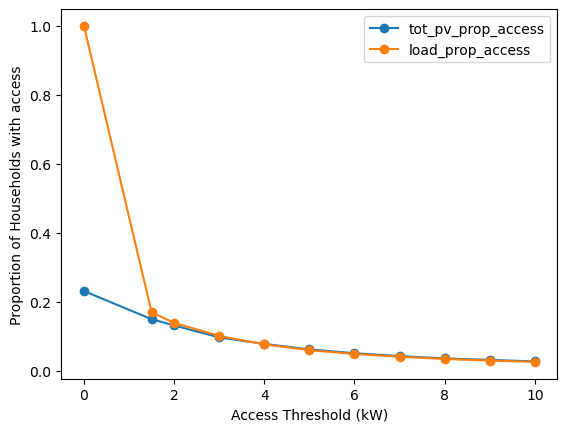

In [51]:
fig, ax = plt.subplots()
summary.plot(ax=ax, x='threshold', marker='o')
ax.set_xlabel('Access Threshold (kW)')
ax.set_ylabel('Proportion of Households with access')
plt.show()

# Census Tract Aggregation

In [52]:
linked = linked.drop(labels=['index_right'], axis=1)
# calculate households per census tract
tract_hh_count = linked.groupby(['GEOID'])['unit'].sum().reset_index(name='zillow_tract_hh_count')

# average der_remain to aggregate up to census tract level
census_der = linked.groupby('GEOID').apply(
    lambda x: pd.Series({
        'avg_DER_remain_pv_hh': np.average(x['DER_remain_pv_hh'], weights=x['unit']),
        'avg_DER_remain_load_hh': np.average(x['DER_remain_load_hh'], weights=x['unit']),
        'avg_DER_total_pv_hh': np.average(x['DER_total_pv_hh'], weights=x['unit']),
    }), include_groups=False
).reset_index()

In [58]:
pge_census_map = census.merge(census_der, on='GEOID')
pge_census_map = pge_census_map.merge(tract_hh_count, on='GEOID')
pge_census_map = pge_census_map[['GEOID', 'zillow_tract_hh_count', 'avg_DER_remain_pv_hh', 'avg_DER_remain_load_hh', 'avg_DER_total_pv_hh', 'geometry']]

In [59]:
pge_census_map.to_parquet('pge_census_map_new.parquet')

**Final Output:** Each census tract (within PGE area) and its respective DER capacities per household.